# Stage 1: Supervised Fine-Tuning (PhoBERT + LoRA)

**Cau hinh moi:**
- LoRA r=16 target [query, key, value] (capacity gap 3-4 lan vs r=8/qv)
- CLASS_WEIGHTS [0.05, 1.0, 2.5, 5.0] - Neutral nang ky de bot bo class
- LR 1e-5, EPOCHS 10, PATIENCE 3

In [1]:
!pip install -q torchao --upgrade
!pip install -q --upgrade transformers peft accelerate sentencepiece
!pip install -q torch pyvi pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 85.2 MB/s eta 0:00:00


In [2]:
import json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
from sklearn.metrics import classification_report, f1_score
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
SEED = 42
MODEL_NAME = "vinai/phobert-base"
MAX_LEN = 256
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ASPECT_COLS = [
    "FACILITIES#CLEANLINESS","FACILITIES#COMFORT","FACILITIES#DESIGN&FEATURES","FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS","FACILITIES#PRICES","FACILITIES#QUALITY","FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES","FOOD&DRINKS#QUALITY","FOOD&DRINKS#STYLE&OPTIONS","HOTEL#CLEANLINESS",
    "HOTEL#COMFORT","HOTEL#DESIGN&FEATURES","HOTEL#GENERAL","HOTEL#MISCELLANEOUS","HOTEL#PRICES",
    "HOTEL#QUALITY","LOCATION#GENERAL","ROOMS#CLEANLINESS","ROOMS#COMFORT","ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL","ROOMS#MISCELLANEOUS","ROOMS#PRICES","ROOMS#QUALITY","ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT","ROOM_AMENITIES#DESIGN&FEATURES","ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS","ROOM_AMENITIES#PRICES","ROOM_AMENITIES#QUALITY","SERVICE#GENERAL",
]
LABEL_NAMES = ["None", "Positive", "Negative", "Neutral"]
N_POLARITIES = len(LABEL_NAMES)
N_ASPECTS    = len(ASPECT_COLS)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Device: {DEVICE}")

Device: cuda


In [4]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR  = Path("/content/drive/MyDrive/task2_dataset")
SAVE_PATH = Path("/content/drive/MyDrive/ABSA_Task2")
SAVE_PATH.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_PATH: {SAVE_PATH}")

Mounted at /content/drive
DATA_DIR : /content/drive/MyDrive/task2_dataset
SAVE_PATH: /content/drive/MyDrive/ABSA_Task2


In [5]:
# LoRA r=16 target query+key+value (capacity lon hon r=8/qv) - bat buoc giong nhau
# giua Stage 1, 2, 3 vi checkpoint phai compatible.
LORA_R           = 16
LORA_ALPHA       = 32
LORA_TARGETS     = ["query", "key", "value"]
LORA_DROPOUT     = 0.1
HEAD_DROPOUT     = 0.2

def build_lora_backbone():
    phobert = AutoModel.from_pretrained(MODEL_NAME)
    return get_peft_model(phobert, LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=LORA_TARGETS,
        lora_dropout=LORA_DROPOUT, bias="none"))

class PhoBertACSA_LoRA(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)

class PhoBertACSA_ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.phobert    = build_lora_backbone()
        self.dropout    = nn.Dropout(HEAD_DROPOUT)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS * N_POLARITIES)
        self.critic     = nn.Linear(self.phobert.config.hidden_size, N_ASPECTS)
    def forward(self, input_ids, attention_mask):
        out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        logits = self.classifier(pooled).view(-1, N_ASPECTS, N_POLARITIES)
        values = self.critic(pooled)
        return logits, values

In [6]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer):
        texts = df["Review"].fillna("").astype(str).tolist()
        tokenized = [ViTokenizer.tokenize(t.lower()) for t in texts]
        self.encodings = tokenizer(tokenized, truncation=True, add_special_tokens=True,
                                   max_length=MAX_LEN, padding="max_length")
        self.labels = df[ASPECT_COLS].astype("int64").to_numpy()
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i], dtype=torch.long) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def make_loader(df, tokenizer, shuffle=False):
    return DataLoader(ABSADataset(df, tokenizer), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0, pin_memory=True)

def compute_metrics(y_true, y_pred):
    ft, fp = y_true.reshape(-1), y_pred.reshape(-1)
    m = {
        "flat_macro_f1": f1_score(ft, fp, labels=list(range(N_POLARITIES)), average="macro", zero_division=0),
        "exact_match":   float(np.mean(np.all(y_true == y_pred, axis=1))),
    }
    mask = ft != 0
    m["non_none_macro_f1"]   = f1_score(ft[mask], fp[mask], labels=[1,2,3], average="macro", zero_division=0) if mask.any() else 0.0
    m["per_aspect_macro_f1"] = float(np.mean([
        f1_score(y_true[:,a], y_pred[:,a], labels=list(range(N_POLARITIES)), average="macro", zero_division=0)
        for a in range(y_true.shape[1])]))
    return m

@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_labels, all_preds, total_loss = [], [], 0.0
    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        out    = model(ids, mask)
        logits = out[0] if isinstance(out, tuple) else out
        if criterion:
            total_loss += criterion(logits.reshape(-1, N_POLARITIES), labels.reshape(-1)).item()
        all_labels.append(labels.cpu().numpy())
        all_preds.append(logits.argmax(-1).cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    m = compute_metrics(y_true, y_pred)
    if criterion:
        m["loss"] = total_loss / max(len(loader), 1)
    m["y_true"] = y_true; m["y_pred"] = y_pred
    return m

def print_metrics(prefix, m):
    keys = ["loss","flat_macro_f1","non_none_macro_f1","per_aspect_macro_f1","exact_match"]
    parts = [f"{k}: {m[k]:.4f}" for k in keys if k in m]
    print(f"{prefix} | " + " | ".join(parts))

In [7]:
tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_df     = pd.read_csv(DATA_DIR / "1-VLSP2018-SA-Hotel-train.csv")
dev_df       = pd.read_csv(DATA_DIR / "2-VLSP2018-SA-Hotel-dev.csv")
test_df      = pd.read_csv(DATA_DIR / "3-VLSP2018-SA-Hotel-test.csv")
train_loader = make_loader(train_df, tokenizer, shuffle=True)
dev_loader   = make_loader(dev_df,   tokenizer)
test_loader  = make_loader(test_df,  tokenizer)
print(f"train {len(train_df)} | dev {len(dev_df)} | test {len(test_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

train 3000 | dev 2000 | test 600


In [8]:
# Hyperparams Stage 1 - tang capacity LoRA + class weights manh hon Neutral
EPOCHS   = 10
LR       = 1e-5
PATIENCE = 3
CLASS_WEIGHTS = torch.tensor([0.05, 1.0, 2.5, 5.0], device=DEVICE)

model     = PhoBertACSA_LoRA().to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
trainable = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable):,}")
optimizer = AdamW(trainable, lr=LR)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.06 * len(train_loader) * EPOCHS)),
    num_training_steps=len(train_loader) * EPOCHS)

history, best_f1, patience_cnt = [], -1.0, 0
best_ckpt = SAVE_PATH / "best_model_sft.bin"

for epoch in range(1, EPOCHS + 1):
    model.train(); total_loss = 0.0
    for batch in train_loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(ids, mask).reshape(-1, N_POLARITIES), labels.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(trainable, 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)
    dev_m = evaluate_model(model, dev_loader, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    **{f"dev_{k}": v for k, v in dev_m.items() if not k.startswith("y_")}})
    # Track theo non_none_macro_f1 thay vi flat - day la metric chinh cua bai
    print_metrics(f"Epoch {epoch}/{EPOCHS} | train_loss {train_loss:.4f}", dev_m)
    score = dev_m["non_none_macro_f1"]
    if score > best_f1:
        best_f1 = score; patience_cnt = 0
        torch.save(model.state_dict(), best_ckpt)
        print(f"  -> saved (non_none_f1 {best_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stop tai epoch {epoch} (best non_none_f1 {best_f1:.4f})"); break

pd.DataFrame(history).to_csv(SAVE_PATH / "stage1_history.csv", index=False)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 989,320
Epoch 1/10 | train_loss 1.3617 | loss: 1.3100 | flat_macro_f1: 0.2029 | non_none_macro_f1: 0.3642 | per_aspect_macro_f1: 0.1446 | exact_match: 0.0000
  -> saved (non_none_f1 0.3642)
Epoch 2/10 | train_loss 1.2574 | loss: 1.2153 | flat_macro_f1: 0.2258 | non_none_macro_f1: 0.4275 | per_aspect_macro_f1: 0.1433 | exact_match: 0.0000
  -> saved (non_none_f1 0.4275)
Epoch 3/10 | train_loss 1.1791 | loss: 1.1591 | flat_macro_f1: 0.2290 | non_none_macro_f1: 0.4518 | per_aspect_macro_f1: 0.1373 | exact_match: 0.0000
  -> saved (non_none_f1 0.4518)
Epoch 4/10 | train_loss 1.1344 | loss: 1.1306 | flat_macro_f1: 0.2282 | non_none_macro_f1: 0.4560 | per_aspect_macro_f1: 0.1335 | exact_match: 0.0000
  -> saved (non_none_f1 0.4560)
Epoch 5/10 | train_loss 1.1128 | loss: 1.1158 | flat_macro_f1: 0.2265 | non_none_macro_f1: 0.4552 | per_aspect_macro_f1: 0.1320 | exact_match: 0.0000
Epoch 6/10 | train_loss 1.1014 | loss: 1.1063 | flat_macro_f1: 0.2246 | non_none_macro_f1: 0.454

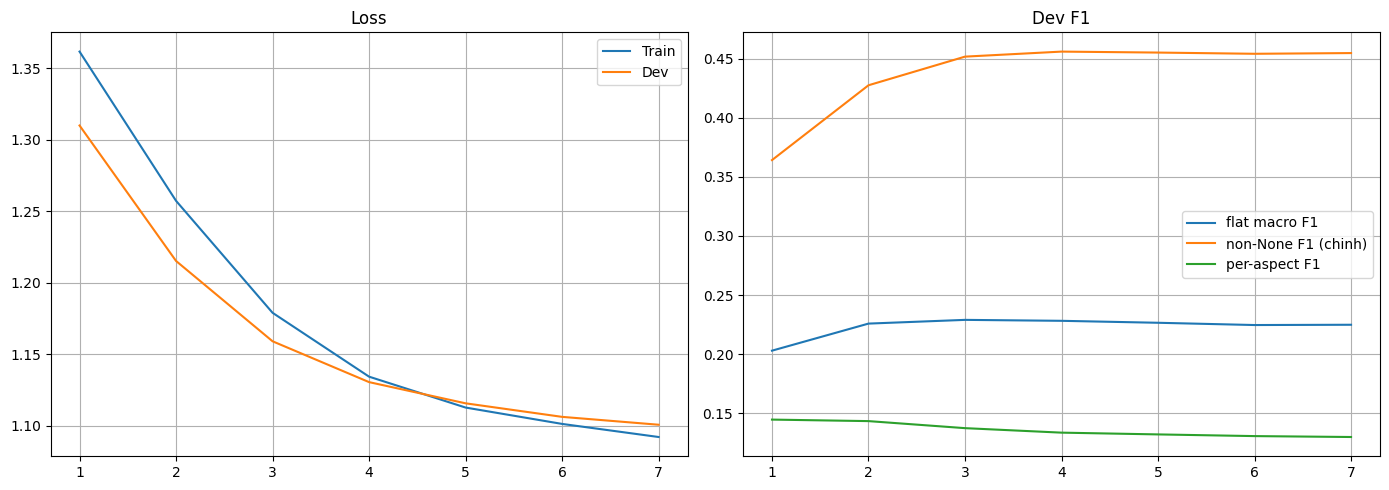

In [9]:
hist = pd.read_csv(SAVE_PATH / "stage1_history.csv")
fig, axs = plt.subplots(1, 2, figsize=(14,5))
axs[0].plot(hist["epoch"], hist["train_loss"], label="Train")
axs[0].plot(hist["epoch"], hist["dev_loss"],   label="Dev")
axs[0].set_title("Loss"); axs[0].legend(); axs[0].grid(True)
axs[1].plot(hist["epoch"], hist["dev_flat_macro_f1"],     label="flat macro F1")
axs[1].plot(hist["epoch"], hist["dev_non_none_macro_f1"], label="non-None F1 (chinh)")
axs[1].plot(hist["epoch"], hist["dev_per_aspect_macro_f1"],label="per-aspect F1")
axs[1].set_title("Dev F1"); axs[1].legend(); axs[1].grid(True)
plt.tight_layout(); plt.show()

In [10]:
model = PhoBertACSA_LoRA().to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH / "best_model_sft.bin", map_location=DEVICE))
test_m = evaluate_model(model, test_loader, criterion)
print_metrics("Stage 1 Test", test_m)
print(classification_report(
    test_m["y_true"].reshape(-1), test_m["y_pred"].reshape(-1),
    labels=list(range(N_POLARITIES)), target_names=LABEL_NAMES, zero_division=0))
with open(SAVE_PATH/"stage1_test_metrics.json","w",encoding="utf-8") as f:
    json.dump({k:float(v) for k,v in test_m.items() if not k.startswith("y_")}, f, indent=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stage 1 Test | loss: 1.1465 | flat_macro_f1: 0.2387 | non_none_macro_f1: 0.4463 | per_aspect_macro_f1: 0.1355 | exact_match: 0.0000
              precision    recall  f1-score   support

        None       0.97      0.39      0.55     17816
    Positive       0.16      0.78      0.26      1806
    Negative       0.08      0.55      0.14       645
     Neutral       0.00      0.00      0.00       133

    accuracy                           0.42     20400
   macro avg       0.30      0.43      0.24     20400
weighted avg       0.86      0.42      0.51     20400

